# 03 - Deep Neural Network Training

In [1]:
import sys
import sklearn
import tensorflow as tf
from tensorflow import keras

%load_ext tensorboard
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

PROJECT_ROOT_DIR = "."
CHAPTER_ID = "deep"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok = True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving Figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    
tf.keras.backend.clear_session()
print("GPU available:", tf.config.list_physical_devices("GPU"))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled


## Vanishing/Exploding Gradients Problem

In [2]:
def logit(z):
    return 1 / (1 + np.exp(z))

Saving Figure sigmoid_saturation_plot


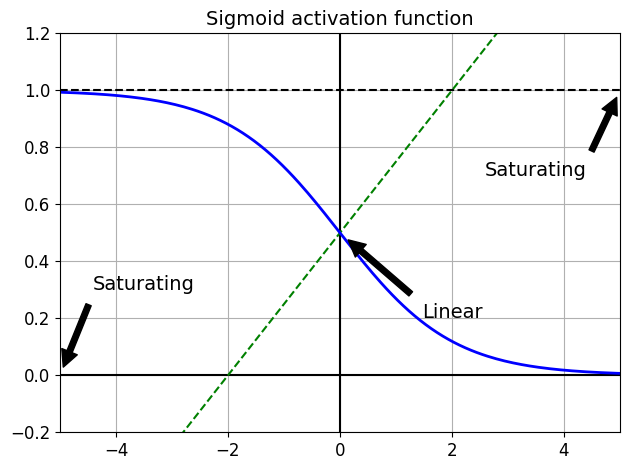

In [3]:
z = np.linspace(-5, 5, 200)
plt.plot([-5,5], [0,0], 'k-')
plt.plot([-5,5], [1,1], 'k--')
plt.plot([0,0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, logit(z), "b-", linewidth=2)

props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props, fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props, fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props, fontsize=14, ha="center")
plt.title("Sigmoid activation function", fontsize=14)

plt.axis([-5, 5, -0.2, 1.2])
plt.grid(True)
save_fig("sigmoid_saturation_plot")
plt.show()

## Xavier and He Initialization

In [4]:
[name for name in dir(keras.initializers) if not name.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'HeNormal',
 'HeUniform',
 'Identity',
 'Initializer',
 'LecunNormal',
 'LecunUniform',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'random_normal',
 'random_uniform',
 'serialize',
 'truncated_normal',
 'variance_scaling',
 'zeros']

In [5]:
keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal")
init = keras.initializers.VarianceScaling(
    scale=2.,
    mode='fan_avg',
    distribution='uniform'
)
keras.layers.Dense(10, activation="relu", kernel_initializer=init)

## Nonsaturating Activation Functions

### Leaky Relu

In [6]:
def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha*z, z)

Saving Figure leaky_relu_plot


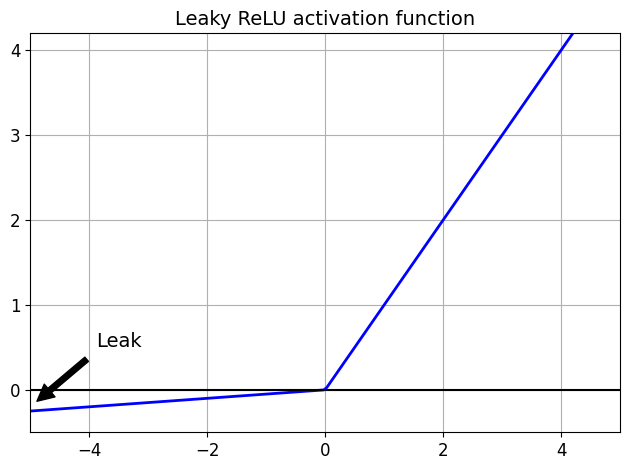

In [7]:
plt.plot(z, leaky_relu(z, 0.05), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
props = dict(facecolor="black", shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.2), arrowprops=props, fontsize=14, ha="center")
plt.grid(True)
plt.title("Leaky ReLU activation function", fontsize=14)
plt.axis([-5, 5, -0.5, 4.2])
save_fig("leaky_relu_plot")
plt.show()

In [8]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'swish',
 'tanh']

In [9]:
[m for m in dir(keras.layers) if "relu" in m.lower()]

['LeakyReLU', 'PReLU', 'ReLU', 'ThresholdedReLU']

#### Let's train a neural network on Fashion MNIST using the Leaky ReLU:

In [10]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0
x_valid, x_train = x_train_full[:5000], x_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [11]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [12]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer=keras.optimizers.SGD(learning_rate=1e-3),
             metrics=['accuracy'])

In [13]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 5s 2ms/step - loss: 1.2459 - accuracy: 0.6122 - val_loss: 0.8664 - val_accuracy: 0.7366
Epoch 2/10
1719/1719 [==============================] - 4s 2ms/step - loss: 0.7797 - accuracy: 0.7595 - val_loss: 0.7016 - val_accuracy: 0.7828
Epoch 3/10
1719/1719 [==============================] - 14s 8ms/step - loss: 0.6702 - accuracy: 0.7881 - val_loss: 0.6337 - val_accuracy: 0.7974
Epoch 4/10
1719/1719 [==============================] - 22s 13ms/step - loss: 0.6123 - accuracy: 0.8035 - val_loss: 0.5814 - val_accuracy: 0.8150
Epoch 5/10
1719/1719 [==============================] - 23s 13ms/step - loss: 0.5751 - accuracy: 0.8136 - val_loss: 0.5507 - val_accuracy: 0.8232
Epoch 6/10
1719/1719 [==============================] - 24s 14ms/step - loss: 0.5484 - accuracy: 0.8193 - val_loss: 0.5283 - val_accuracy: 0.8300
Epoch 7/10
1719/1719 [==============================] - 24s 14ms/step - loss: 0.5283 - accuracy: 0.8254 - val_loss: 0.5100 - val_

### Now let's try PReLU:

In [14]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 28s 16ms/step - loss: 1.3663 - accuracy: 0.6010 - val_loss: 0.8989 - val_accuracy: 0.7282
Epoch 2/10
1719/1719 [==============================] - 26s 15ms/step - loss: 0.8016 - accuracy: 0.7499 - val_loss: 0.7086 - val_accuracy: 0.7804
Epoch 3/10
1719/1719 [==============================] - 27s 16ms/step - loss: 0.6822 - accuracy: 0.7802 - val_loss: 0.6402 - val_accuracy: 0.7988
Epoch 4/10
1719/1719 [==============================] - 26s 15ms/step - loss: 0.6221 - accuracy: 0.7964 - val_loss: 0.5879 - val_accuracy: 0.8100
Epoch 5/10
1719/1719 [==============================] - 25s 14ms/step - loss: 0.5838 - accuracy: 0.8060 - val_loss: 0.5557 - val_accuracy: 0.8186
Epoch 6/10
1719/1719 [==============================] - 26s 15ms/step - loss: 0.5562 - accuracy: 0.8123 - val_loss: 0.5333 - val_accuracy: 0.8232
Epoch 7/10
1719/1719 [==============================] - 30s 18ms/step - loss: 0.5352 - accuracy: 0.8180 - val_loss: 0.5142 -

### ELU - Exponential Linear Unit

In [15]:
def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

Saving Figure elu_plot


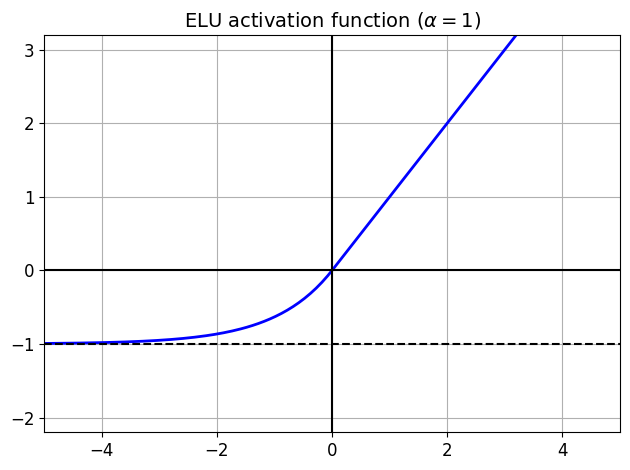

In [16]:
plt.plot(z, elu(z), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k--')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.title(r"ELU activation function ($\alpha=1$)", fontsize=14)
plt.axis([-5, 5, -2.2, 3.2])
save_fig("elu_plot")
plt.show()

Implementing ELU in TensorFlow is trivial, just specify the activation function when building each layer:

In [17]:
keras.layers.Dense(10, activation="elu")

### SELU
During training, a neural network composed exclusively of a stack of dense layers using the SELU activation function and LeCun initialization will self-normalize: the output of each layer will tend to preserve the same mean and variance during training, which solves the vanishing/exploding gradients problem. As a result, this activation function outperforms the other activation functions very significantly for such neural nets, so you should really try it out. Unfortunately, the self-normalizing property of the SELU activation function is easily broken: you cannot use ℓ1 or ℓ2 regularization, regular dropout, max-norm, skip connections or other non-sequential topologies (so recurrent neural networks won't self-normalize). However, in practice it works quite well with sequential CNNs. If you break self-normalization, SELU will not necessarily outperform other activation functions.

In [18]:
from scipy.special import erfc
# alpha and scale to self normalize with mean 0 and standard deviation 1
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1/np.sqrt(2)) * np.exp(1/2) - 1)
scale_0_1 = (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e)) * np.sqrt(2 * np.pi) * (2 * erfc(np.sqrt(2))*np.e**2 + np.pi*erfc(1/np.sqrt(2))**2*np.e - 2*(2+np.pi)*erfc(1/np.sqrt(2))*np.sqrt(np.e)+np.pi+2)**(-1/2)

In [19]:
def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

Saving Figure selu_plot


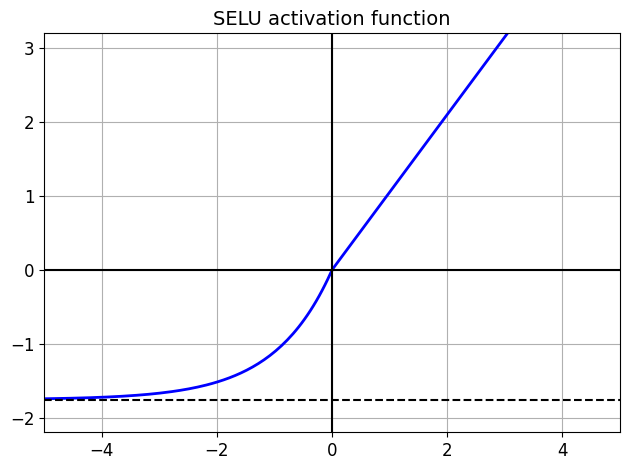

In [20]:
plt.plot(z, selu(z), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1.758, -1.758], 'k--')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.title("SELU activation function", fontsize=14)
plt.axis([-5, 5, -2.2, 3.2])

save_fig("selu_plot")
plt.show()

By default, the SELU hyperparameters (scale and alpha) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem:

In [21]:
np.random.seed(42)
z = np.random.normal(size=(500, 100))
for layer in range(1000):
    w = np.random.normal(size=(100, 100), scale = np.sqrt(1/100))
    z = selu(np.dot(z, w))
    means = np.mean(z, axis=0).mean()
    stds = np.std(z, axis=0).mean()
    if layer % 100 == 0:
            print("Layer {}: mean {:.2f}, std deviation {:.2f}".format(layer, means, stds))

Layer 0: mean -0.00, std deviation 1.00
Layer 100: mean 0.02, std deviation 0.96
Layer 200: mean 0.01, std deviation 0.90
Layer 300: mean -0.02, std deviation 0.92
Layer 400: mean 0.05, std deviation 0.89
Layer 500: mean 0.01, std deviation 0.93
Layer 600: mean 0.02, std deviation 0.92
Layer 700: mean -0.02, std deviation 0.90
Layer 800: mean 0.05, std deviation 0.83
Layer 900: mean 0.02, std deviation 1.00


Using SELU is easy:

In [22]:
keras.layers.Dense(10, activation="selu",
                   kernel_initializer="lecun_normal")

Let's create a neural net for Fashion MNIST with 100 hidden layers, using the SELU activation function:

In [23]:
np.random.seed(42)
tf.random.set_seed(42)
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="selu",
                             kernel_initializer="lecun_normal"))
for layer in range(99):
    model.add(keras.layers.Dense(100, activation="selu",
                                 kernel_initializer="lecun_normal"))
model.add(keras.layers.Dense(10, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

Now let's train it. Do not forget to scale the inputs to mean 0 and standard deviation 1:

In [24]:
pixel_means = x_train.mean(axis=0, keepdims=True)
pixel_stds = x_train.std(axis=0, keepdims=True)
x_train_scaled = (x_train - pixel_means) / pixel_stds
x_valid_scaled = (x_valid - pixel_means) / pixel_stds
x_test_scaled = (x_test - pixel_means) / pixel_stds

history = model.fit(x_train_scaled, y_train, epochs=5,
                    validation_data=(x_valid_scaled, y_valid))

Epoch 1/5
1719/1719 [==============================] - 150s 80ms/step - loss: 1.0786 - accuracy: 0.6086 - val_loss: 0.7424 - val_accuracy: 0.7460
Epoch 2/5
1719/1719 [==============================] - 131s 76ms/step - loss: 0.6724 - accuracy: 0.7609 - val_loss: 0.5923 - val_accuracy: 0.7970
Epoch 3/5
1719/1719 [==============================] - 129s 75ms/step - loss: 0.5659 - accuracy: 0.8033 - val_loss: 0.5465 - val_accuracy: 0.8124
Epoch 4/5
1719/1719 [==============================] - 141s 82ms/step - loss: 0.5267 - accuracy: 0.8200 - val_loss: 0.4966 - val_accuracy: 0.8310
Epoch 5/5
1719/1719 [==============================] - 129s 75ms/step - loss: 0.5360 - accuracy: 0.8162 - val_loss: 0.4904 - val_accuracy: 0.8386


Now look at what happens if we try to use the ReLU activation function instead:

In [25]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"))
for layer in range(99):
    model.add(keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(keras.layers.Dense(10, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])
history = model.fit(x_train_scaled, y_train, epochs=5,
                    validation_data=(x_valid_scaled, y_valid))

Epoch 1/5
1719/1719 [==============================] - 143s 77ms/step - loss: 1.9194 - accuracy: 0.2329 - val_loss: 1.4097 - val_accuracy: 0.3996
Epoch 2/5
1719/1719 [==============================] - 128s 74ms/step - loss: 1.4142 - accuracy: 0.3888 - val_loss: 1.3056 - val_accuracy: 0.4720
Epoch 3/5
1719/1719 [==============================] - 131s 76ms/step - loss: 1.1377 - accuracy: 0.5086 - val_loss: 0.9241 - val_accuracy: 0.6398
Epoch 4/5
1719/1719 [==============================] - 131s 76ms/step - loss: 0.9975 - accuracy: 0.5823 - val_loss: 0.8888 - val_accuracy: 0.6606
Epoch 5/5
1719/1719 [==============================] - 126s 73ms/step - loss: 0.8336 - accuracy: 0.6567 - val_loss: 0.8092 - val_accuracy: 0.6510


## Batch Normalization

In [26]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")   
])
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 batch_normalization (BatchN  (None, 784)              3136      
 ormalization)                                                   
                                                                 
 dense_212 (Dense)           (None, 300)               235500    
                                                                 
 batch_normalization_1 (Batc  (None, 300)              1200      
 hNormalization)                                                 
                                                                 
 dense_213 (Dense)           (None, 100)               30100     
                                                                 
 batch_normalization_2 (Batc  (None, 100)             

In [27]:
bn1 = model.layers[1]
[(var.name, var.trainable) for var in bn1.variables]

[('batch_normalization/gamma:0', True),
 ('batch_normalization/beta:0', True),
 ('batch_normalization/moving_mean:0', False),
 ('batch_normalization/moving_variance:0', False)]

In [28]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer=keras.optimizers.SGD(learning_rate=1e-3),
             metrics=["accuracy"])

history = model.fit(x_train, y_train, epochs=10,
                   validation_data=(x_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 39s 21ms/step - loss: 0.8573 - accuracy: 0.7114 - val_loss: 0.5633 - val_accuracy: 0.8156
Epoch 2/10
1719/1719 [==============================] - 37s 21ms/step - loss: 0.5731 - accuracy: 0.8016 - val_loss: 0.4808 - val_accuracy: 0.8442
Epoch 3/10
1719/1719 [==============================] - 37s 22ms/step - loss: 0.5148 - accuracy: 0.8213 - val_loss: 0.4457 - val_accuracy: 0.8518
Epoch 4/10
1719/1719 [==============================] - 37s 21ms/step - loss: 0.4760 - accuracy: 0.8343 - val_loss: 0.4229 - val_accuracy: 0.8580
Epoch 5/10
1719/1719 [==============================] - 37s 22ms/step - loss: 0.4505 - accuracy: 0.8409 - val_loss: 0.4074 - val_accuracy: 0.8598
Epoch 6/10
1719/1719 [==============================] - 37s 22ms/step - loss: 0.4370 - accuracy: 0.8462 - val_loss: 0.3961 - val_accuracy: 0.8638
Epoch 7/10
1719/1719 [==============================] - 37s 21ms/step - loss: 0.4224 - accuracy: 0.8515 - val_loss: 0.3865 -

Sometimes applying BN before the activation function works better (there's a debate on this topic). Moreover, the layer before a `BatchNormalization` layer does not need to have bias terms, since the `BatchNormalization` layer has some as well, it would be a waste of parameters, so you can set `use_bias=False` when creating those layers:

In [29]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dense(100, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dense(10, activation="softmax")
    
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])


history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_valid, y_valid))

Epoch 1/10
1719/1719 [==============================] - 40s 22ms/step - loss: 1.0574 - accuracy: 0.6743 - val_loss: 0.6745 - val_accuracy: 0.7998
Epoch 2/10
1719/1719 [==============================] - 36s 21ms/step - loss: 0.6805 - accuracy: 0.7838 - val_loss: 0.5522 - val_accuracy: 0.8198
Epoch 3/10
1719/1719 [==============================] - 37s 21ms/step - loss: 0.5946 - accuracy: 0.8048 - val_loss: 0.4977 - val_accuracy: 0.8364
Epoch 4/10
1719/1719 [==============================] - 35s 20ms/step - loss: 0.5438 - accuracy: 0.8202 - val_loss: 0.4650 - val_accuracy: 0.8456
Epoch 5/10
1719/1719 [==============================] - 36s 21ms/step - loss: 0.5091 - accuracy: 0.8278 - val_loss: 0.4425 - val_accuracy: 0.8512
Epoch 6/10
1719/1719 [==============================] - 35s 20ms/step - loss: 0.4879 - accuracy: 0.8337 - val_loss: 0.4256 - val_accuracy: 0.8532
Epoch 7/10
1719/1719 [==============================] - 36s 21ms/step - loss: 0.4711 - accuracy: 0.8383 - val_loss: 0.4111 -

## Gradient Clipping
All Keras optimizers accept `clipnorm` or `clipvalue` arguments:

In [30]:
optimizer = keras.optimizers.SGD(clipvalue=1.0)

In [31]:
optimizer = keras.optimizers.SGD(clipnorm=1.0)

## Reusing Pretrained Layers
### Reusing a Keras model
Let's split the fashion MNIST training set in two:

- `X_train_A`: all images of all items except for sandals and shirts (classes 5 and 6).
- `X_train_B` : a much smaller training set of just the first 200 images of sandals or shirts.

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (sneakers, ankle boots, coats, t-shirts, etc.) are somewhat similar to classes in set B (sandals and shirts). However, since we are using Dense layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the CNN).

In [32]:
def split_dataset(x, y):
    y_5_or_6 = (y == 5) | (y == 6) # sandals or shirts
    y_A = y[~y_5_or_6]
    y_A[y_A > 6 ] -=2 #class indices 7, 8, 9 should be moved to 5, 6, 7
    y_B = (y[y_5_or_6])
    y_B = (y[y_5_or_6] == 6).astype(np.float32) # binary classification task: is it a shirt (class 6)?
    return ((x[~y_5_or_6], y_A),
            (x[y_5_or_6], y_B))

(x_train_A, y_train_A), (x_train_B, y_train_B) = split_dataset(x_train, y_train)
(x_valid_A, y_valid_A), (x_valid_B, y_valid_B) = split_dataset(x_valid, y_valid)
(x_test_A, y_test_A), (x_test_B, y_test_B) = split_dataset(x_test, y_test)
x_train_B = x_train_B[:200]
y_train_B = y_train_B[:200]

In [33]:
x_train_A.shape

(43986, 28, 28)

In [34]:
x_train_B.shape

(200, 28, 28)

In [35]:
y_train_A[:30]

array([4, 0, 5, 7, 7, 7, 4, 4, 3, 4, 0, 1, 6, 3, 4, 3, 2, 6, 5, 3, 4, 5,
       1, 3, 4, 2, 0, 6, 7, 1], dtype=uint8)

In [36]:
y_train_B[:30]

array([1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1.], dtype=float32)

In [37]:
tf.random.set_seed(42)
np.random.seed(42)

In [38]:
model_A = keras.models.Sequential()
model_A.add(keras.layers.Flatten(input_shape=[28, 28]))
for n_hidden in (300, 100, 50, 50, 50):
    model_A.add(keras.layers.Dense(n_hidden, activation="selu"))
model_A.add(keras.layers.Dense(8, activation="softmax"))

In [39]:
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                metrics=["accuracy"])

In [40]:
history = model_A.fit(x_train_A, y_train_A, epochs=20,
                    validation_data=(x_valid_A, y_valid_A))

Epoch 1/20
1375/1375 [==============================] - 21s 15ms/step - loss: 0.5931 - accuracy: 0.8115 - val_loss: 0.3831 - val_accuracy: 0.8687
Epoch 2/20
1375/1375 [==============================] - 20s 15ms/step - loss: 0.3553 - accuracy: 0.8793 - val_loss: 0.3212 - val_accuracy: 0.8876
Epoch 3/20
1375/1375 [==============================] - 20s 14ms/step - loss: 0.3172 - accuracy: 0.8908 - val_loss: 0.2936 - val_accuracy: 0.8979
Epoch 4/20
1375/1375 [==============================] - 20s 14ms/step - loss: 0.2970 - accuracy: 0.8976 - val_loss: 0.2803 - val_accuracy: 0.9028
Epoch 5/20
1375/1375 [==============================] - 20s 14ms/step - loss: 0.2834 - accuracy: 0.9012 - val_loss: 0.2695 - val_accuracy: 0.9058
Epoch 6/20
1375/1375 [==============================] - 20s 14ms/step - loss: 0.2737 - accuracy: 0.9050 - val_loss: 0.2674 - val_accuracy: 0.9058
Epoch 7/20
1375/1375 [==============================] - 19s 14ms/step - loss: 0.2653 - accuracy: 0.9081 - val_loss: 0.2625 -

In [41]:
model_A.save("my_model_A.keras")

In [42]:
model_B = keras.models.Sequential()
model_B.add(keras.layers.Flatten(input_shape=[28, 28]))
for n_hidden in (300, 100, 50, 50, 50):
    model_B.add(keras.layers.Dense(n_hidden, activation="selu"))
model_B.add(keras.layers.Dense(1, activation="sigmoid"))


model_B.compile(loss="binary_crossentropy",
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                metrics=["accuracy"])

history = model_B.fit(x_train_B, y_train_B, epochs=20,
                      validation_data=(x_valid_B, y_valid_B))

Epoch 1/20
7/7 [==============================] - 3s 155ms/step - loss: 0.6062 - accuracy: 0.7050 - val_loss: 0.4843 - val_accuracy: 0.7789
Epoch 2/20
7/7 [==============================] - 0s 70ms/step - loss: 0.4023 - accuracy: 0.8550 - val_loss: 0.3611 - val_accuracy: 0.8773
Epoch 3/20
7/7 [==============================] - 0s 68ms/step - loss: 0.2973 - accuracy: 0.9250 - val_loss: 0.2902 - val_accuracy: 0.9209
Epoch 4/20
7/7 [==============================] - 0s 68ms/step - loss: 0.2347 - accuracy: 0.9500 - val_loss: 0.2455 - val_accuracy: 0.9371
Epoch 5/20
7/7 [==============================] - 0s 69ms/step - loss: 0.1942 - accuracy: 0.9700 - val_loss: 0.2147 - val_accuracy: 0.9544
Epoch 6/20
7/7 [==============================] - 0s 70ms/step - loss: 0.1656 - accuracy: 0.9800 - val_loss: 0.1919 - val_accuracy: 0.9615
Epoch 7/20
7/7 [==============================] - 0s 74ms/step - loss: 0.1444 - accuracy: 0.9800 - val_loss: 0.1765 - val_accuracy: 0.9625
Epoch 8/20
7/7 [==========

In [43]:
model_B.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_7 (Flatten)         (None, 784)               0         
                                                                 
 dense_224 (Dense)           (None, 300)               235500    
                                                                 
 dense_225 (Dense)           (None, 100)               30100     
                                                                 
 dense_226 (Dense)           (None, 50)                5050      
                                                                 
 dense_227 (Dense)           (None, 50)                2550      
                                                                 
 dense_228 (Dense)           (None, 50)                2550      
                                                                 
 dense_229 (Dense)           (None, 1)                

In [44]:
model_A = keras.models.load_model("my_model_A.keras")
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

Note that `model_B_on_A` and `model_A` actually share layers now, so when we train one, it will update both models. If we want to avoid that, we need to build `model_B_on_A` on top of a clone of `model_A`:

In [45]:
model_A_clone = keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())
model_B_on_A = keras.models.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

In [46]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                     metrics=["accuracy"])

In [47]:
history = model_B_on_A.fit(x_train_B, y_train_B, epochs=4,
                           validation_data=(x_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(learning_rate=1e-3),
                     metrics=["accuracy"])
history = model_B_on_A.fit(x_train_B, y_train_B, epochs=16,
                           validation_data=(x_valid_B, y_valid_B))

Epoch 1/4
7/7 [==============================] - 3s 159ms/step - loss: 1.0670 - accuracy: 0.3750 - val_loss: 1.0431 - val_accuracy: 0.4391
Epoch 2/4
7/7 [==============================] - 0s 70ms/step - loss: 0.9661 - accuracy: 0.4550 - val_loss: 0.9506 - val_accuracy: 0.4929
Epoch 3/4
7/7 [==============================] - 0s 71ms/step - loss: 0.8759 - accuracy: 0.5250 - val_loss: 0.8700 - val_accuracy: 0.5365
Epoch 4/4
7/7 [==============================] - 0s 66ms/step - loss: 0.7974 - accuracy: 0.6000 - val_loss: 0.7985 - val_accuracy: 0.5680
Epoch 1/16
7/7 [==============================] - 2s 147ms/step - loss: 0.6106 - accuracy: 0.6800 - val_loss: 0.4777 - val_accuracy: 0.7789
Epoch 2/16
7/7 [==============================] - 0s 72ms/step - loss: 0.3671 - accuracy: 0.8400 - val_loss: 0.3309 - val_accuracy: 0.8803
Epoch 3/16
7/7 [==============================] - 0s 69ms/step - loss: 0.2544 - accuracy: 0.9550 - val_loss: 0.2503 - val_accuracy: 0.9239
Epoch 4/16
7/7 [=============

In [48]:
model_B.evaluate(x_test_B, y_test_B)

63/63 [==============================] - 1s 10ms/step - loss: 0.0833 - accuracy: 0.9830


[0.08332981914281845, 0.9829999804496765]

In [49]:
model_B_on_A.evaluate(x_test_B, y_test_B)

63/63 [==============================] - 1s 10ms/step - loss: 0.0645 - accuracy: 0.9910


[0.06452249735593796, 0.9909999966621399]

Great! We got quite a bit of transfer: the error rate dropped by a factor of 4.9!

In [50]:
(100 - 99.75) / (100 - 99.29)

0.3521126760563411

## Faster Optimizers
### Momentum optimization

In [51]:
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

### Nesterov Accelerated Gradient

In [52]:
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

### AdaGrad

In [53]:
optimizer = keras.optimizers.Adagrad(learning_rate=0.001)

### RMSProp

In [54]:
optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

### Adam Optimization

In [55]:
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

### Adamax Optimization

In [56]:
optimizer = keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

### Nadam Optimization

In [57]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

## Learning Rate Scheduling
### Power Scheduling
`lr = lr0 / (1 + steps / s)**c`

- Keras uses `c=1` and `s = 1 / decay`

In [58]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, decay=1e-4)

In [59]:
lr_schedule = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000,
    end_learning_rate=0.001,
    power=1.0
)

optimizer = keras.optimizers.SGD(
    learning_rate=lr_schedule
)

model = keras.models.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer, metrics=["accuracy"])
n_epochs = 25
history = model.fit(x_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(x_valid_scaled, y_valid))


Epoch 1/25
1719/1719 [==============================] - 24s 13ms/step - loss: 0.4854 - accuracy: 0.8281 - val_loss: 0.4020 - val_accuracy: 0.8606
Epoch 2/25
1719/1719 [==============================] - 21s 12ms/step - loss: 0.3781 - accuracy: 0.8658 - val_loss: 0.3724 - val_accuracy: 0.8710
Epoch 3/25
1719/1719 [==============================] - 22s 13ms/step - loss: 0.3457 - accuracy: 0.8774 - val_loss: 0.3733 - val_accuracy: 0.8706
Epoch 4/25
1719/1719 [==============================] - 22s 13ms/step - loss: 0.3249 - accuracy: 0.8850 - val_loss: 0.3531 - val_accuracy: 0.8776
Epoch 5/25
1719/1719 [==============================] - 24s 14ms/step - loss: 0.3108 - accuracy: 0.8902 - val_loss: 0.3479 - val_accuracy: 0.8752
Epoch 6/25
1719/1719 [==============================] - 16s 9ms/step - loss: 0.2996 - accuracy: 0.8950 - val_loss: 0.3465 - val_accuracy: 0.8764
Epoch 7/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2947 - accuracy: 0.8970 - val_loss: 0.3439 - va

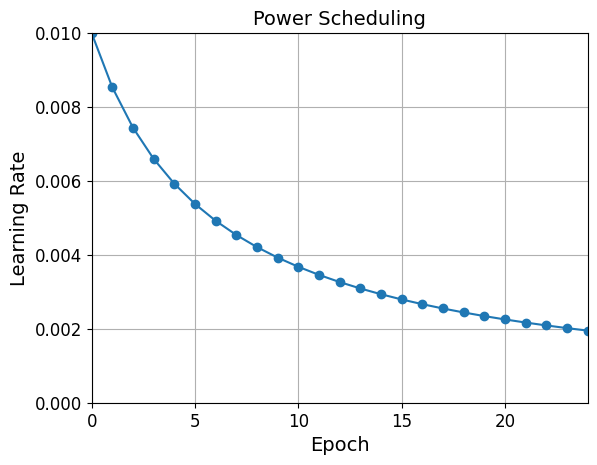

In [60]:
import math

learning_rate = 0.01
decay = 1e-4
batch_size = 32
n_steps_per_epoch = math.ceil(len(x_train) / batch_size)
epochs = np.arange(n_epochs)
lrs = learning_rate / (1 + decay * epochs * n_steps_per_epoch)

plt.plot(epochs, lrs, "o-")
plt.axis([0, n_epochs -1, 0, 0.01])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.grid(True)
plt.show()

### Exponential Scheduling
`lr = lr0 * 0.1**(epoch / s)`

In [61]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1**(epoch/20)

In [62]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1**(epoch / s)
    return exponential_decay_fn

exponential_decay_fn =  exponential_decay(lr0=0.01, s=20)

model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])

class LrLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs["lr"] = self.model.optimizer.learning_rate.numpy()
n_epochs = 25

lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)
lr_logger = LrLogger()

history = model.fit(
    x_train_scaled, y_train,
    epochs=n_epochs,
    validation_data=(x_valid_scaled, y_valid),
    callbacks=[lr_scheduler, lr_logger])

Epoch 1/25
1719/1719 [==============================] - 7s 4ms/step - loss: 6.8260 - accuracy: 0.2105 - val_loss: 6.6269 - val_accuracy: 0.2692 - lr: 0.0100
Epoch 2/25
1719/1719 [==============================] - 6s 4ms/step - loss: 7.9357 - accuracy: 0.2459 - val_loss: 7.1476 - val_accuracy: 0.2212 - lr: 0.0089
Epoch 3/25
1719/1719 [==============================] - 8s 4ms/step - loss: 6.8498 - accuracy: 0.1574 - val_loss: 5.9224 - val_accuracy: 0.1600 - lr: 0.0079
Epoch 4/25
1719/1719 [==============================] - 7s 4ms/step - loss: 4.8615 - accuracy: 0.1327 - val_loss: 4.5384 - val_accuracy: 0.1072 - lr: 0.0071
Epoch 5/25
1719/1719 [==============================] - 7s 4ms/step - loss: 4.5445 - accuracy: 0.1167 - val_loss: 4.5384 - val_accuracy: 0.1072 - lr: 0.0063
Epoch 6/25
1719/1719 [==============================] - 7s 4ms/step - loss: 4.5445 - accuracy: 0.1167 - val_loss: 4.5384 - val_accuracy: 0.1072 - lr: 0.0056
Epoch 7/25
1719/1719 [==============================] - 7s

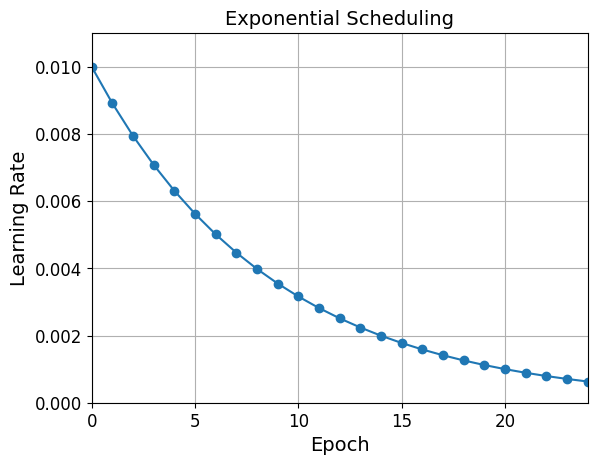

In [63]:
plt.plot(history.epoch, history.history["lr"], "o-")
plt.axis([0, n_epochs - 1, 0, 0.011])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.grid(True)
plt.show()

The schedule function can take the current learning rate as a second argument:

In [64]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1**(1 / 20)

If you want to update the learning rate at each iteration rather than at each epoch, you must write your own callback class:

In [65]:
class ExponentialDecayPerBatch(keras.callbacks.Callback):
    def __init__(self, lr0, s):
        super().__init__()
        self.lr0 = lr0          # initial learning rate
        self.s = s              # decay steps
        self.step = 0           # global step counter
        self.lrs = []           # store LR history

    def on_train_batch_begin(self, batch, logs=None):
        lr = self.lr0 * 0.1 ** (self.step / self.s)
        self.model.optimizer.learning_rate.assign(lr)

        self.lrs.append(lr)
        self.step += 1
lr0 = 0.01
batch_size = 32
n_epochs = 25

s = 20 * len(x_train) // batch_size
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])

optimizer = keras.optimizers.Nadam(learning_rate=lr0)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

exp_decay = ExponentialDecayPerBatch(lr0=lr0, s=s)
history = model.fit(
    x_train_scaled, y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    validation_data=(x_valid_scaled, y_valid),
    callbacks=[exp_decay]
)


Epoch 1/25
1719/1719 [==============================] - 9s 5ms/step - loss: 0.7908 - accuracy: 0.7666 - val_loss: 0.8553 - val_accuracy: 0.7498
Epoch 2/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.6212 - accuracy: 0.8102 - val_loss: 0.5508 - val_accuracy: 0.8364
Epoch 3/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.6111 - accuracy: 0.8181 - val_loss: 0.7050 - val_accuracy: 0.8178
Epoch 4/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5983 - accuracy: 0.8280 - val_loss: 0.5537 - val_accuracy: 0.8430
Epoch 5/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.5433 - accuracy: 0.8483 - val_loss: 0.5781 - val_accuracy: 0.8500
Epoch 6/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4858 - accuracy: 0.8573 - val_loss: 0.5425 - val_accuracy: 0.8616
Epoch 7/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4394 - accuracy: 0.8695 - val_loss: 0.5513 - val_accuracy:

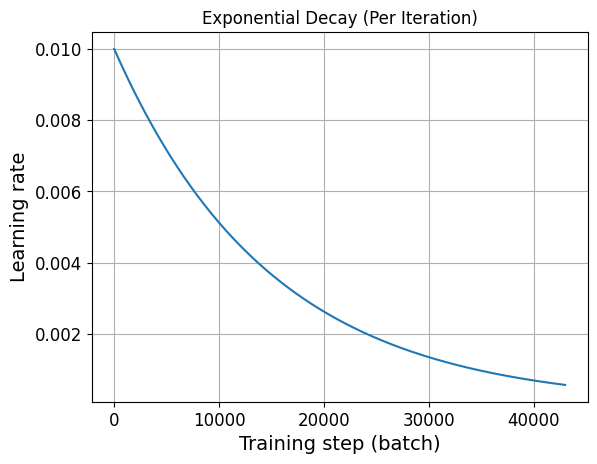

In [66]:
plt.plot(exp_decay.lrs)
plt.xlabel("Training step (batch)")
plt.ylabel("Learning rate")
plt.title("Exponential Decay (Per Iteration)")
plt.grid(True)
plt.show()

### Piecewise Constant Scheduling

In [67]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

In [68]:
def piecewise_constant(boundaries, values):
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    def piecewise_constant_fn(epoch):
        return values[np.argmax(boundaries > epoch) - 1]
    return piecewise_constant_fn

piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

lr_scheduler = keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 25
history = model.fit(x_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(x_valid_scaled, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.8470 - accuracy: 0.7569 - val_loss: 1.0165 - val_accuracy: 0.6626 - lr: 0.0100
Epoch 2/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.8862 - accuracy: 0.7482 - val_loss: 0.7448 - val_accuracy: 0.8008 - lr: 0.0100
Epoch 3/25
1719/1719 [==============================] - 8s 5ms/step - loss: 0.7955 - accuracy: 0.7703 - val_loss: 0.8827 - val_accuracy: 0.7458 - lr: 0.0100
Epoch 4/25
1719/1719 [==============================] - 7s 4ms/step - loss: 1.2903 - accuracy: 0.5989 - val_loss: 1.2301 - val_accuracy: 0.5390 - lr: 0.0100
Epoch 5/25
1719/1719 [==============================] - 9s 5ms/step - loss: 1.2415 - accuracy: 0.5859 - val_loss: 1.0709 - val_accuracy: 0.6154 - lr: 0.0100
Epoch 6/25
1719/1719 [==============================] - 8s 4ms/step - loss: 0.7907 - accuracy: 0.7347 - val_loss: 0.6625 - val_accuracy: 0.8290 - lr: 0.0050
Epoch 7/25
1719/1719 [==============================] - 7s

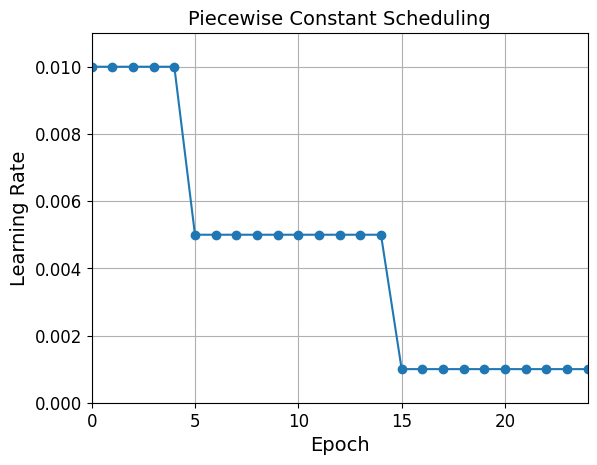

In [69]:
plt.plot(history.epoch, [piecewise_constant_fn(epoch) for epoch in history.epoch], "o-")
plt.axis([0, n_epochs - 1, 0, 0.011])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Piecewise Constant Scheduling", fontsize=14)
plt.grid(True)
plt.show()

### Performance Scheduling

In [70]:
tf.random.set_seed(42)
np.random.seed(42)

Epoch 1/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.5969 - accuracy: 0.8059 - val_loss: 0.5103 - val_accuracy: 0.8462 - lr: 0.0200
Epoch 2/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4928 - accuracy: 0.8409 - val_loss: 0.5827 - val_accuracy: 0.8286 - lr: 0.0200
Epoch 3/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5166 - accuracy: 0.8406 - val_loss: 0.4868 - val_accuracy: 0.8660 - lr: 0.0200
Epoch 4/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5254 - accuracy: 0.8449 - val_loss: 0.5164 - val_accuracy: 0.8468 - lr: 0.0200
Epoch 5/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.5165 - accuracy: 0.8498 - val_loss: 0.4689 - val_accuracy: 0.8538 - lr: 0.0200
Epoch 6/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4928 - accuracy: 0.8561 - val_loss: 0.5022 - val_accuracy: 0.8658 - lr: 0.0200
Epoch 7/25
1719/1719 [==============================] - 4s

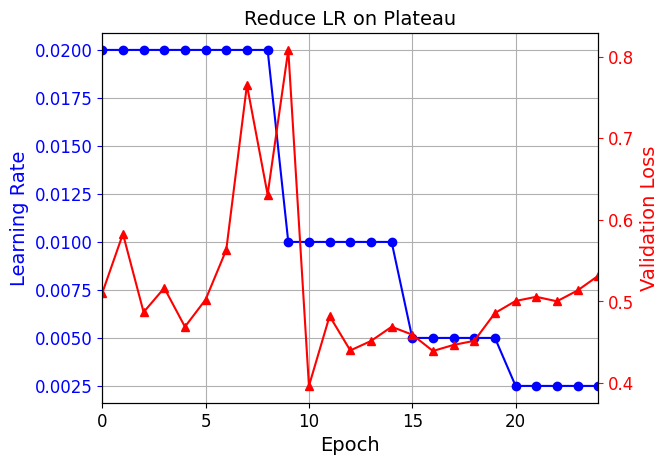

In [71]:
class LrLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs["lr"] = float(self.model.optimizer.learning_rate)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=5,
    verbose=1
)

lr_logger = LrLogger()
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])

optimizer = keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
n_epochs = 25

history = model.fit(
    x_train_scaled, y_train,
    epochs=n_epochs,
    validation_data=(x_valid_scaled, y_valid),
    callbacks=[lr_scheduler, lr_logger]
)

plt.plot(history.epoch, history.history["lr"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params(axis='y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel("Validation Loss", color='r')
ax2.tick_params(axis='y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()


### tf.keras schedulers

In [72]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
s = 20 * len(x_train) // 32 # number of steps in 20 epochs (batch size = 32)
learning_rate = keras.optimizers.schedules.ExponentialDecay(0.01, s, 0.1)
optimizer = keras.optimizers.SGD(learning_rate)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
n_epochs = 25
history = model.fit(x_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(x_valid_scaled, y_valid))

Epoch 1/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.4882 - accuracy: 0.8284 - val_loss: 0.3993 - val_accuracy: 0.8602
Epoch 2/25
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3807 - accuracy: 0.8650 - val_loss: 0.3697 - val_accuracy: 0.8726
Epoch 3/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3465 - accuracy: 0.8767 - val_loss: 0.3747 - val_accuracy: 0.8698
Epoch 4/25
1719/1719 [==============================] - 4s 3ms/step - loss: 0.3251 - accuracy: 0.8838 - val_loss: 0.3471 - val_accuracy: 0.8800
Epoch 5/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3084 - accuracy: 0.8901 - val_loss: 0.3409 - val_accuracy: 0.8792
Epoch 6/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2941 - accuracy: 0.8956 - val_loss: 0.3414 - val_accuracy: 0.8834
Epoch 7/25
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2838 - accuracy: 0.8986 - val_loss: 0.3369 - val_accuracy:

For piecewise constant scheduling, try this:

In [73]:
learning_rate = keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[5. * n_steps_per_epoch, 15. * n_steps_per_epoch],
    values=[0.01, 0.005, 0.001])

### 1Cycle scheduling

In [74]:
import math
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        super().__init__()
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = float(self.model.optimizer.learning_rate.numpy())
        self.rates.append(lr)
        self.losses.append(logs["loss"])
        self.model.optimizer.learning_rate.assign(lr * self.factor)

def find_learning_rate(model, x, y,
                       epochs=1,
                       batch_size=32,
                       min_rate=1e-5,
                       max_rate=10):

    init_weights = model.get_weights()
    original_lr = model.optimizer.learning_rate
    model.optimizer.learning_rate = tf.Variable(min_rate, dtype=tf.float32)
    iterations = math.ceil(len(x) / batch_size) * epochs
    factor = np.exp(np.log(max_rate / min_rate) / iterations)
    exp_lr = ExponentialLearningRate(factor)

    model.fit(
        x, y,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[exp_lr],
        verbose=0
    )

    model.optimizer.learning_rate = original_lr
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses
    
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses)
    plt.gca().set_xscale('log')
    plt.hlines(min(losses), min(rates), max(rates))
    plt.axis([
        min(rates),
        max(rates),
        min(losses),
        (losses[0] + min(losses)) / 2
    ])
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

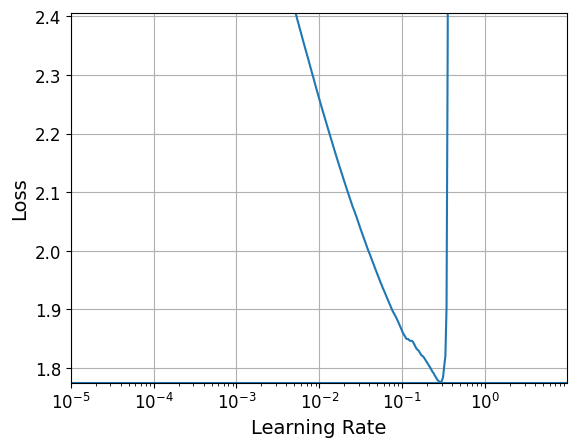

In [75]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=["accuracy"]
)
batch_size = 128
rates, losses = find_learning_rate(
    model,
    x_train_scaled,
    y_train,
    epochs=1,
    batch_size=batch_size
)
plot_lr_vs_loss(rates, losses)

In [76]:
class OneCycleScheduler(keras.callbacks.Callback):
    def __init__(self, iterations, max_rate,
                 start_rate=None,
                 last_iterations=None,
                 last_rate=None):
        super().__init__()
        self.iterations = iterations
        self.max_rate = max_rate
        self.start_rate = start_rate or max_rate / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_rate = last_rate or self.start_rate / 1000
        self.iteration = 0
        self.rates = []  # optional: store LR history

    def _interpolate(self, iter1, iter2, rate1, rate2):
        return ((rate2 - rate1) * (self.iteration - iter1)
                / (iter2 - iter1) + rate1)

    def on_train_batch_begin(self, batch, logs=None):
        if self.iteration < self.half_iteration:
            rate = self._interpolate(
                0, self.half_iteration,
                self.start_rate, self.max_rate
            )
        elif self.iteration < 2 * self.half_iteration:
            rate = self._interpolate(
                self.half_iteration, 2 * self.half_iteration,
                self.max_rate, self.start_rate
            )
        else:
            rate = self._interpolate(
                2 * self.half_iteration, self.iterations,
                self.start_rate, self.last_rate
            )

        self.model.optimizer.learning_rate.assign(rate)
        self.rates.append(rate)

        self.iteration += 1


In [77]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
batch_size = 32
n_epochs = 25

total_iterations = math.ceil(len(x_train) / batch_size) * n_epochs

onecycle = OneCycleScheduler(
    iterations=total_iterations,
    max_rate=0.05
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    validation_data=(x_valid_scaled, y_valid),
    callbacks=[onecycle]
)

Epoch 1/25
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4748 - accuracy: 0.8319 - val_loss: 0.3939 - val_accuracy: 0.8546
Epoch 2/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3925 - accuracy: 0.8606 - val_loss: 0.4443 - val_accuracy: 0.8544
Epoch 3/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4057 - accuracy: 0.8563 - val_loss: 0.4167 - val_accuracy: 0.8632
Epoch 4/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4720 - accuracy: 0.8477 - val_loss: 0.6319 - val_accuracy: 0.8346
Epoch 5/25
1719/1719 [==============================] - 5s 3ms/step - loss: 0.6625 - accuracy: 0.8230 - val_loss: 0.6137 - val_accuracy: 0.8114
Epoch 6/25
1719/1719 [==============================] - 5s 3ms/step - loss: 1.0699 - accuracy: 0.7734 - val_loss: 1.8144 - val_accuracy: 0.6958
Epoch 7/25
1719/1719 [==============================] - 5s 3ms/step - loss: 3.0888 - accuracy: 0.3585 - val_loss: 4.2858 - val_accuracy:

## Avoiding Overfitting Troough Regularization

### l1 and l2 regularization

In [78]:
layer = keras.layers.Dense(100, activation="elu",
                          kernel_initializer="he_normal",
                          kernel_regularizer= keras.regularizers.l2(0.01))
# or l1(0.1) for ℓ1 regularization with a factor of 0.1
# or l1_l2(0.1, 0.01) for both ℓ1 and ℓ2 regularization, with factors 0.1 and 0.01 respectively

In [79]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="elu",
                      kernel_initializer="he_normal",
                      kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(100, activation="elu",
                      kernel_initializer="he_normal",
                      kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(10, activation="softmax",
                      kernel_regularizer=keras.regularizers.l2(0.01))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 2
history = model.fit(x_train_scaled, y_train, epochs=n_epochs, 
                   validation_data=(x_valid_scaled, y_valid))

Epoch 1/2
1719/1719 [==============================] - 9s 5ms/step - loss: 1.5950 - accuracy: 0.8111 - val_loss: 0.7197 - val_accuracy: 0.8290
Epoch 2/2
1719/1719 [==============================] - 8s 5ms/step - loss: 0.7195 - accuracy: 0.8272 - val_loss: 0.6844 - val_accuracy: 0.8366


In [80]:
from functools import partial

RegularizedDense = partial(keras.layers.Dense,
                          activation="elu",
                          kernel_initializer="he_normal",
                          kernel_regularizer=keras.regularizers.l2(0.01))

model = keras.models.Sequential([
    keras.layers.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    RegularizedDense(300),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 2
history = model.fit(x_train_scaled, y_train, epochs=n_epochs, 
                   validation_data=(x_valid_scaled, y_valid))

Epoch 1/2
1719/1719 [==============================] - 8s 4ms/step - loss: 1.6629 - accuracy: 0.8126 - val_loss: 0.7169 - val_accuracy: 0.8326
Epoch 2/2
1719/1719 [==============================] - 8s 4ms/step - loss: 0.7165 - accuracy: 0.8284 - val_loss: 0.6802 - val_accuracy: 0.8380


### Dropout

In [81]:

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(300, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 2
history = model.fit(x_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(x_valid_scaled, y_valid))

Epoch 1/2
1719/1719 [==============================] - 9s 5ms/step - loss: 0.5756 - accuracy: 0.8010 - val_loss: 0.3622 - val_accuracy: 0.8672
Epoch 2/2
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4236 - accuracy: 0.8454 - val_loss: 0.3424 - val_accuracy: 0.8744


### Alpha Dropout

In [82]:
tf.random.set_seed(42)
np.random.seed(42)

In [83]:

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])
optimizer = keras.optimizers.SGD(learning_rate=0.03, momentum=0.9, nesterov=True)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
early_stop = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train_scaled,
    y_train,
    epochs=20,
    validation_data=(x_valid_scaled, y_valid),
    callbacks=[early_stop]
)

Epoch 1/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7861 - accuracy: 0.7351 - val_loss: 0.8524 - val_accuracy: 0.7954
Epoch 2/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7247 - accuracy: 0.7588 - val_loss: 0.7990 - val_accuracy: 0.8026
Epoch 3/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7182 - accuracy: 0.7625 - val_loss: 0.7891 - val_accuracy: 0.7902
Epoch 4/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7348 - accuracy: 0.7601 - val_loss: 0.6414 - val_accuracy: 0.8250
Epoch 5/20
1719/1719 [==============================] - 6s 3ms/step - loss: 0.7396 - accuracy: 0.7601 - val_loss: 0.6103 - val_accuracy: 0.8166
Epoch 6/20
1719/1719 [==============================] - 6s 3ms/step - loss: 0.7435 - accuracy: 0.7628 - val_loss: 0.7878 - val_accuracy: 0.8316
Epoch 7/20
1719/1719 [==============================] - 6s 3ms/step - loss: 0.7537 - accuracy: 0.7600 - val_loss: 0.7735 - val_accuracy:

In [84]:
model.evaluate(x_test_scaled, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.6872 - accuracy: 0.7997


[0.6872116327285767, 0.7997000217437744]

In [85]:
model.evaluate(x_train_scaled, y_train)

1719/1719 [==============================] - 3s 2ms/step - loss: 0.5725 - accuracy: 0.8141


[0.5724673867225647, 0.8140909075737]

In [86]:
history = model.fit(x_train_scaled, y_train)

1719/1719 [==============================] - 4s 2ms/step - loss: 0.7447 - accuracy: 0.7608


### MC Dropout

In [87]:
tf.random.set_seed(42)
np.random.seed(42)

In [88]:
MC_SAMPLES = 50        # 100 ki jagah 50 (safe)
BATCH_SIZE = 32       # tumne already 32 rakha hai 

y_probas = []

n_test = x_test_scaled.shape[0]

for i in range(MC_SAMPLES):
    preds_all = []

    for start in range(0, n_test, BATCH_SIZE):
        end = start + BATCH_SIZE
        batch = x_test_scaled[start:end]

        # ensure float32 + tensor
        batch = tf.convert_to_tensor(batch, dtype=tf.float32)

        preds = model(batch, training=True)  # dropout ON
        preds_all.append(preds.numpy())

    preds_all = np.vstack(preds_all)
    y_probas.append(preds_all)

y_probas = np.stack(y_probas)

y_proba = y_probas.mean(axis=0)
y_std   = y_probas.std(axis=0)

In [89]:
np.round(model.predict(x_test_scaled[:1]), 2)

1/1 [==============================] - 0s 106ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.98]],
      dtype=float32)

In [90]:
np.round(y_probas[:, :1], 2)

array([[[0.  , 0.  , 0.  , 0.  , 0.  , 0.09, 0.  , 0.22, 0.  , 0.69]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.01]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.01, 0.  , 0.99]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.04, 0.  , 0.02, 0.03, 0.9 ]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  ]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.99]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.47, 0.  , 0.04, 0.  , 0.49]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  ]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.2 , 0.  , 0.8 ]],

       [[0.09, 0.  , 0.09, 0.01, 0.17, 0.36, 0.07, 0.02, 0.06, 0.14]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  ]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.99]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.27, 0.  , 0.05, 0.  , 0.68]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.23, 0.  , 0.05, 0.01, 0

In [91]:
np.round(y_proba[:1], 2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.13, 0.  , 0.05, 0.01, 0.8 ]],
      dtype=float32)

In [92]:
y_std = y_probas.std(axis=0)
np.round(y_std[:1], 2)

array([[0.01, 0.  , 0.01, 0.  , 0.02, 0.25, 0.01, 0.09, 0.04, 0.29]],
      dtype=float32)

In [93]:
y_pred = np.argmax(y_proba, axis=1)

In [94]:
accuracy = np.sum(y_pred == y_test) / len(y_test)
accuracy

0.8131

In [95]:
class MCDropout(keras.layers.Dropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

In [96]:
tf.random.set_seed(42)
np.random.seed(42)

In [97]:
mc_model = keras.models.Sequential([
    MCAlphaDropout(layer.rate) if isinstance(layer, keras.layers.AlphaDropout) else layer
    for layer in model.layers
])

In [98]:
mc_model.summary()

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_19 (Flatten)        (None, 784)               0         
                                                                 
 mc_alpha_dropout (MCAlphaDr  (None, 784)              0         
 opout)                                                          
                                                                 
 dense_265 (Dense)           (None, 300)               235500    
                                                                 
 mc_alpha_dropout_1 (MCAlpha  (None, 300)              0         
 Dropout)                                                        
                                                                 
 dense_266 (Dense)           (None, 100)               30100     
                                                                 
 mc_alpha_dropout_2 (MCAlpha  (None, 100)            

In [99]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
mc_model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [100]:
mc_model.set_weights(model.get_weights())

Now we can use the model with MC Dropout:

In [101]:
np.round(np.mean([mc_model.predict(x_test_scaled[:1]) for sample in range(100)], axis=0), 2)

1/1 [==============================] - 0s 21ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.13, 0.  , 0.08, 0.02, 0.78]],
      dtype=float32)

### Max norm

In [102]:
layer = keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal",
                           kernel_constraint=keras.constraints.max_norm(1.))

In [103]:
MaxNormDense = partial(keras.layers.Dense,
                       activation="selu", kernel_initializer="lecun_normal",
                       kernel_constraint=keras.constraints.max_norm(1.))

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    MaxNormDense(300),
    MaxNormDense(100),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
n_epochs = 2
history = model.fit(x_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(x_valid_scaled, y_valid))

Epoch 1/2
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4770 - accuracy: 0.8324 - val_loss: 0.3723 - val_accuracy: 0.8662
Epoch 2/2
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3542 - accuracy: 0.8712 - val_loss: 0.3750 - val_accuracy: 0.8670


## Exercises
###  Deep Learning on CIFAR10

### a.
Exercise: Build a DNN with 20 hidden layers of 100 neurons each (that's too many, but it's the point of this exercise). Use He initialization and the ELU activation function.

In [111]:
import tensorflow as tf
import keras
import numpy as np
import os
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU memory growth enabled")

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add((keras.layers.Dense(100, 
                                 activation="elu",
                                 kernel_initializer="he_normal")))

GPU memory growth enabled


### b.
Exercise: Using Nadam optimization and early stopping, train the network on the CIFAR10 dataset. You can load it with keras.datasets.cifar10.load_data(). The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes, so you'll need a softmax output layer with 10 neurons. Remember to search for the right learning rate each time you change the model's architecture or hyperparameters.

Let's add the output layer to the model:

In [112]:
model.add(keras.layers.Dense(10, activation="softmax"))

Let's use a Nadam optimizer with a learning rate of 5e-5. I tried learning rates 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3 and 1e-2, and I compared their learning curves for 10 epochs each (using the TensorBoard callback, below). The learning rates 3e-5 and 1e-4 were pretty good, so I tried 5e-5, which turned out to be slightly better.

In [113]:
optimizer = keras.optimizers.Nadam(learning_rate=5e-5)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

Let's load the CIFAR10 dataset. We also want to use early stopping, so we need a validation set. Let's use the first 5,000 images of the original training set as the validation set:

In [114]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train_full[5000:]
y_train = y_train_full[5000:]
x_valid = x_train_full[:5000]
y_valid = y_train_full[:5000]

Now we can create the callbacks we need and train the model:

In [115]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20)
model_checkpoint_cb = keras.callbacks.ModelCheckpoint("my_cifar10_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = os.path.join(os.curdir, "my_cifar10_logs", "run_{:03d}".format(run_index))
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

In [116]:
#%tensorboard --logdir=./my_cifar10_logs --port=6006

In [117]:
model.fit(x_train, y_train, epochs=100, batch_size=64, validation_data=(x_valid, y_valid),
          callbacks=callbacks,
          verbose=1)

Epoch 1/100
704/704 [==============================] - 13s 16ms/step - loss: 4.7994 - accuracy: 0.1598 - val_loss: 2.6859 - val_accuracy: 0.1614
Epoch 2/100
704/704 [==============================] - 10s 15ms/step - loss: 2.1690 - accuracy: 0.2252 - val_loss: 2.6800 - val_accuracy: 0.1848
Epoch 3/100
704/704 [==============================] - 10s 14ms/step - loss: 2.0343 - accuracy: 0.2612 - val_loss: 2.5612 - val_accuracy: 0.1862
Epoch 4/100
704/704 [==============================] - 10s 14ms/step - loss: 1.9480 - accuracy: 0.2902 - val_loss: 2.5067 - val_accuracy: 0.1980
Epoch 5/100
704/704 [==============================] - 10s 14ms/step - loss: 1.8813 - accuracy: 0.3153 - val_loss: 2.3174 - val_accuracy: 0.2316
Epoch 6/100
704/704 [==============================] - 9s 13ms/step - loss: 1.8304 - accuracy: 0.3355 - val_loss: 1.8907 - val_accuracy: 0.3118
Epoch 7/100
704/704 [==============================] - 9s 13ms/step - loss: 1.7789 - accuracy: 0.3567 - val_loss: 1.9712 - val_accu

In [118]:
model = keras.models.load_model("my_cifar10_model.keras")
model.evaluate(x_valid, y_valid)

157/157 [==============================] - 1s 3ms/step - loss: 1.5302 - accuracy: 0.4664


[1.5302047729492188, 0.46639999747276306]

The model with the lowest validation loss gets about 47.6% accuracy on the validation set. It took 27 epochs to reach the lowest validation loss, with roughly 8 seconds per epoch on my laptop (without a GPU). Let's see if we can improve performance using Batch Normalization.

### c.
Exercise: Now try adding Batch Normalization and compare the learning curves: Is it converging faster than before? Does it produce a better model? How does it affect training speed?

The code below is very similar to the code above, with a few changes:

I added a BN layer after every Dense layer (before the activation function), except for the output layer. I also added a BN layer before the first hidden layer.
I changed the learning rate to 5e-4. I experimented with 1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 5e-4, 1e-3 and 3e-3, and I chose the one with the best validation performance after 20 epochs.
I renamed the run directories to run_bn_* and the model file name to my_cifar10_bn_model.keras.

In [119]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
model.add(keras.layers.BatchNormalization())
for _ in range(20):
    model.add(keras.layers.Dense(100, kernel_initializer="he_normal"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation("elu"))
model.add(keras.layers.Dense(10, activation="softmax"))

optimizer = keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=20)
model_checkpoint_cb = keras.callbacks.ModelCheckpoint("my_cifar10_bn_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = os.path.join(os.curdir, "my_cifar10_logs", "run_bn_{:03d}".format(run_index))
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(x_train, y_train, epochs=100,
          validation_data=(x_valid, y_valid),
          callbacks=callbacks)

model = keras.models.load_model("my_cifar10_bn_model.keras")
model.evaluate(x_valid, y_valid)

Epoch 1/100
1407/1407 [==============================] - 55s 35ms/step - loss: 1.8388 - accuracy: 0.3413 - val_loss: 1.6700 - val_accuracy: 0.3970
Epoch 2/100
1407/1407 [==============================] - 48s 34ms/step - loss: 1.6669 - accuracy: 0.4053 - val_loss: 1.6313 - val_accuracy: 0.4126
Epoch 3/100
1407/1407 [==============================] - 50s 35ms/step - loss: 1.5963 - accuracy: 0.4326 - val_loss: 1.5393 - val_accuracy: 0.4384
Epoch 4/100
1407/1407 [==============================] - 51s 36ms/step - loss: 1.5474 - accuracy: 0.4503 - val_loss: 1.5181 - val_accuracy: 0.4634
Epoch 5/100
1407/1407 [==============================] - 49s 35ms/step - loss: 1.5051 - accuracy: 0.4670 - val_loss: 1.4382 - val_accuracy: 0.4888
Epoch 6/100
1407/1407 [==============================] - 49s 35ms/step - loss: 1.4643 - accuracy: 0.4785 - val_loss: 1.4223 - val_accuracy: 0.4934
Epoch 7/100
1407/1407 [==============================] - 50s 35ms/step - loss: 1.4323 - accuracy: 0.4919 - val_loss: 1

[1.3301270008087158, 0.5432000160217285]

- Is the model converging faster than before? Much faster! The previous model took 27 epochs to reach the lowest validation loss, while the new model achieved that same loss in just 5 epochs and continued to make progress until the 16th epoch. The BN layers stabilized training and allowed us to use a much larger learning rate, so convergence was faster.
- Does BN produce a better model? Yes! The final model is also much better, with 54.0% accuracy instead of 47.6%. It's still not a very good model, but at least it's much better than before (a Convolutional Neural Network would do much better, but that's a different topic, see chapter 14).
- How does BN affect training speed? Although the model converged much faster, each epoch took about 12s instead of 8s, because of the extra computations required by the BN layers. But overall the training time (wall time) was shortened significantly!

### d.
Exercise: Try replacing Batch Normalization with SELU, and make the necessary adjustements to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.).

In [120]:
import tensorflow as tf
import keras
import numpy as np
import os
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU memory growth enabled")

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

x_train = x_train.astype("float32")
x_valid = x_valid.astype("float32")
x_test  = x_test.astype("float32")

x_means = x_train.mean(axis=0)
x_stds  = x_train.std(axis=0) + 1e-7

x_train_scaled = (x_train - x_means) / x_stds
x_valid_scaled = (x_valid - x_means) / x_stds
x_test_scaled  = (x_test  - x_means) / x_stds

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))

for _ in range(20):
    model.add(
        keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal"
        )
    )

model.add(keras.layers.Dense(10, activation="softmax"))

optimizer = keras.optimizers.Nadam(learning_rate=7e-4)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

model_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "my_cifar10_selu_model.keras",
    save_best_only=True
)

run_index = 1
run_logdir = os.path.join("my_cifar10_logs", f"run_selu_{run_index:03d}")
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

with tf.device("/CPU:0"):
    history = model.fit(
        x_train_scaled,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(x_valid_scaled, y_valid),
        callbacks=callbacks,
        verbose=1
    )
model = keras.models.load_model("my_cifar10_selu_model.keras")
model.evaluate(x_valid_scaled, y_valid)

GPU memory growth enabled
Epoch 1/100
1407/1407 [==============================] - 48s 32ms/step - loss: 1.9443 - accuracy: 0.3051 - val_loss: 1.8865 - val_accuracy: 0.3290
Epoch 2/100
1407/1407 [==============================] - 44s 32ms/step - loss: 1.7324 - accuracy: 0.3869 - val_loss: 1.7739 - val_accuracy: 0.3504
Epoch 3/100
1407/1407 [==============================] - 45s 32ms/step - loss: 1.6313 - accuracy: 0.4274 - val_loss: 1.6604 - val_accuracy: 0.3932
Epoch 4/100
1407/1407 [==============================] - 46s 33ms/step - loss: 1.5616 - accuracy: 0.4516 - val_loss: 1.6229 - val_accuracy: 0.4380
Epoch 5/100
1407/1407 [==============================] - 43s 30ms/step - loss: 1.5047 - accuracy: 0.4734 - val_loss: 1.6988 - val_accuracy: 0.4084
Epoch 6/100
1407/1407 [==============================] - 43s 30ms/step - loss: 1.4472 - accuracy: 0.4930 - val_loss: 1.5409 - val_accuracy: 0.4588
Epoch 7/100
1407/1407 [==============================] - 44s 31ms/step - loss: 1.4063 - accu

[1.47982919216156, 0.503000020980835]


We get 47.9% accuracy, which is not much better than the original model (47.6%), and not as good as the model using batch normalization (54.0%). However, convergence was almost as fast as with the BN model, plus each epoch took only 7 seconds. So it's by far the fastest model to train so far.

### e.
Exercise: Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC Dropout.

In [121]:
import tensorflow as tf
import keras
import numpy as np
import os
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU memory growth enabled")

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

x_train = x_train.astype("float32")
x_valid = x_valid.astype("float32")
x_test  = x_test.astype("float32")

x_means = x_train.mean(axis=0)
x_stds  = x_train.std(axis=0) + 1e-7

x_train_scaled = (x_train - x_means) / x_stds
x_valid_scaled = (x_valid - x_means) / x_stds
x_test_scaled  = (x_test  - x_means) / x_stds
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=(32, 32, 3)))

for _ in range(20):
    model.add(
        keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal"
        )
    )

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(keras.layers.Dense(10, activation="softmax"))

optimizer = keras.optimizers.Nadam(learning_rate=5e-4)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

model_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "my_cifar10_alpha_dropout_model.keras",
    save_best_only=True
)

run_index = 1
run_logdir = os.path.join(
    "my_cifar10_logs",
    f"run_alpha_dropout_{run_index:03d}"
)

tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

with tf.device("/CPU:0"):
    history = model.fit(
        x_train_scaled,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(x_valid_scaled, y_valid),
        callbacks=callbacks,
        verbose=1
    )
model = keras.models.load_model("my_cifar10_alpha_dropout_model.keras")
model.evaluate(x_valid_scaled, y_valid)

GPU memory growth enabled
Epoch 1/100
1407/1407 [==============================] - 47s 32ms/step - loss: 1.8842 - accuracy: 0.3289 - val_loss: 1.7223 - val_accuracy: 0.4056
Epoch 2/100
1407/1407 [==============================] - 43s 31ms/step - loss: 1.6531 - accuracy: 0.4217 - val_loss: 1.7626 - val_accuracy: 0.3952
Epoch 3/100
1407/1407 [==============================] - 45s 32ms/step - loss: 1.5682 - accuracy: 0.4543 - val_loss: 1.6521 - val_accuracy: 0.4396
Epoch 4/100
1407/1407 [==============================] - 43s 31ms/step - loss: 1.5021 - accuracy: 0.4732 - val_loss: 1.6054 - val_accuracy: 0.4448
Epoch 5/100
1407/1407 [==============================] - 44s 31ms/step - loss: 1.4508 - accuracy: 0.4963 - val_loss: 1.5874 - val_accuracy: 0.4594
Epoch 6/100
1407/1407 [==============================] - 44s 31ms/step - loss: 1.3981 - accuracy: 0.5171 - val_loss: 1.5233 - val_accuracy: 0.4714
Epoch 7/100
1407/1407 [==============================] - 45s 32ms/step - loss: 1.3561 - accu

[1.5003730058670044, 0.4997999966144562]

The model reaches 48.9% accuracy on the validation set. That's very slightly better than without dropout (47.6%). With an extensive hyperparameter search, it might be possible to do better (I tried dropout rates of 5%, 10%, 20% and 40%, and learning rates 1e-4, 3e-4, 5e-4, and 1e-3), but probably not much better in this case.


Let's use MC Dropout now. We will need the MCAlphaDropout class we used earlier, so let's just copy it here for convenience:

In [122]:
class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)


Now let's create a new model, identical to the one we just trained (with the same weights), but with MCAlphaDropout dropout layers instead of AlphaDropout layers:

In [123]:
mc_model = keras.models.Sequential([
    MCAlphaDropout(layer.rate) if isinstance(layer, keras.layers.AlphaDropout) else layer
    for layer in model.layers
])

Then let's add a couple utility functions. The first will run the model many times (10 by default) and it will return the mean predicted class probabilities. The second will use these mean probabilities to predict the most likely class for each instance:

In [124]:
def mc_dropout_predict_probas(mc_model, x, n_samples=10):
    y_probas = [mc_model.predict(x) for sample in range(n_samples)]
    return np.mean(y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, x, n_samples=10):
    y_probas = mc_dropout_predict_probas(mc_model, x, n_samples)
    return np.argmax(y_probas, axis=1)

Now let's make predictions for all the instances in the validation set, and compute the accuracy:

In [125]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

y_pred = mc_dropout_predict_classes(mc_model, x_valid_scaled)
accuracy = np.mean(y_pred == y_valid[:, 0])
accuracy

157/157 [==============================] - 0s 2ms/step


0.4988

We get no accuracy improvement in this case (we're still at 48.9% accuracy).

So the best model we got in this exercise is the Batch Normalization model.

### f.
Exercise: Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.

In [126]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=(32, 32, 3)))

for _ in range(20):
    model.add(
        keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal"
        )
    )

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(keras.layers.Dense(10, activation="softmax"))

optimizer = keras.optimizers.SGD(learning_rate=1e-3)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [127]:
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        super().__init__()
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        self.rates.append(
            float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        )
        self.losses.append(logs["loss"])
        self.model.optimizer.learning_rate.assign(
            self.model.optimizer.learning_rate * self.factor
        )


def find_learning_rate(
    model, x, y,
    epochs=1,
    batch_size=128,
    min_rate=1e-6,
    max_rate=1
):
    x = x.astype("float32")
    y = y.astype("int64")

    init_weights = model.get_weights()
    original_lr = tf.keras.backend.get_value(model.optimizer.learning_rate)

    iterations = (len(x) // batch_size) * epochs
    factor = np.exp(np.log(max_rate / min_rate) / iterations)

    model.optimizer.learning_rate.assign(min_rate)
    exp_lr = ExponentialLearningRate(factor)

    with tf.device("/CPU:0"):
        model.fit(
            x, y,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[exp_lr],
            verbose=0
        )

    model.optimizer.learning_rate.assign(original_lr)
    model.set_weights(init_weights)

    return exp_lr.rates, exp_lr.losses

In [128]:
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses)
    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.grid(True)

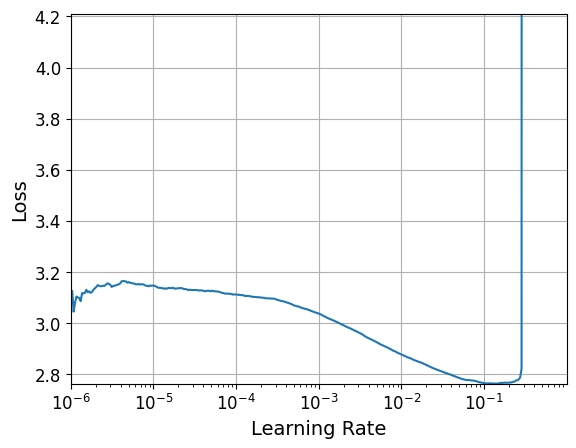

In [129]:
batch_size = 128

rates, losses = find_learning_rate(
    model,
    x_train_scaled,
    y_train,
    epochs=1,
    batch_size=batch_size
)

plot_lr_vs_loss(rates, losses)
plt.axis([
    min(rates),
    max(rates),
    min(losses),
    (losses[0] + min(losses)) / 1.4
])
plt.show()

In [130]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(keras.layers.Dense(100,
                                 kernel_initializer="lecun_normal",
                                 activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(keras.layers.Dense(10, activation="softmax"))

optimizer = keras.optimizers.SGD(learning_rate=1e-2)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

n_epochs = 15
onecycle = OneCycleScheduler(math.ceil(len(x_train_scaled) / batch_size) * n_epochs, max_rate=0.05)
history = model.fit(x_train_scaled, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(x_valid_scaled, y_valid),
                    callbacks=[onecycle])

Epoch 1/15
352/352 [==============================] - 3s 7ms/step - loss: 2.0570 - accuracy: 0.2839 - val_loss: 1.7681 - val_accuracy: 0.3676
Epoch 2/15
352/352 [==============================] - 2s 6ms/step - loss: 1.7596 - accuracy: 0.3780 - val_loss: 1.6528 - val_accuracy: 0.4180
Epoch 3/15
352/352 [==============================] - 2s 6ms/step - loss: 1.6277 - accuracy: 0.4226 - val_loss: 1.6584 - val_accuracy: 0.4156
Epoch 4/15
352/352 [==============================] - 2s 7ms/step - loss: 1.5511 - accuracy: 0.4499 - val_loss: 1.6266 - val_accuracy: 0.4306
Epoch 5/15
352/352 [==============================] - 2s 6ms/step - loss: 1.4940 - accuracy: 0.4707 - val_loss: 1.5951 - val_accuracy: 0.4594
Epoch 6/15
352/352 [==============================] - 2s 6ms/step - loss: 1.4532 - accuracy: 0.4860 - val_loss: 1.5598 - val_accuracy: 0.4598
Epoch 7/15
352/352 [==============================] - 2s 6ms/step - loss: 1.4142 - accuracy: 0.4992 - val_loss: 1.6040 - val_accuracy: 0.4526
Epoch 

One cycle allowed us to train the model in just 15 epochs, each taking only 2 seconds (thanks to the larger batch size). This is several times faster than the fastest model we trained so far. Moreover, we improved the model's performance (from 47.6% to 52.0%). The batch normalized model reaches a slightly better performance (54%), but it's much slower to train.